In [41]:
##-- load libraries --##
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [42]:
# index event borrow
dfx = pd.read_csv('./x_index_borrow_train.csv')
dfx.head(1)

,id,type,timestamp,user,pool,reserve,amount,amountUSD,amountETH,borrowRate,...,sinDayOfQuarter,cosDayOfQuarter,sinDayOfYear,cosDayOfYear,sinQuarter,cosQuarter,isWeekend,logAmount,logAmountUSD,logAmountETH
0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,1.606841e+09,0xbd723fc4f1d737dcfc48a07fe7336766d34cad5f,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.0,1.001646,0.00214,1.25,...,-0.957253,-0.289252,-0.478734,0.87796,-2.449294e-16,1.0,False,0.693147,0.69397,0.002138


In [43]:
# index event borrow to outcome event liquidated
dfy = pd.read_csv('./y_outcome_liquidated_train.csv')
dfy.head(1)

,timeDiff,status,id,Index Event,Outcome Event
0,49806576.0,0.0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,account liquidated


In [44]:
features = list(dfy.keys())
features

['timeDiff', 'status', 'id', 'Index Event', 'Outcome Event']

### Non-parametric model [Kaplan Meier Curve]

Text(0, 0.5, 'Probability')

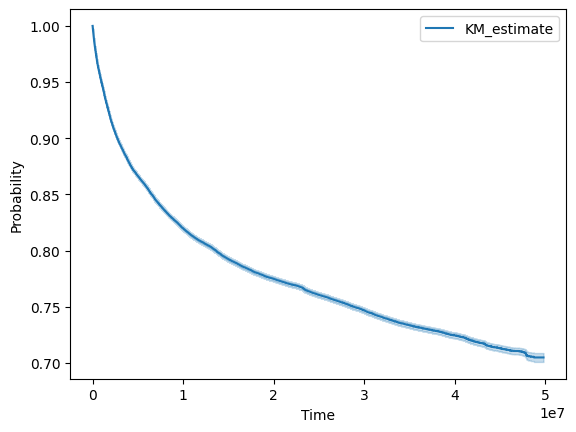

In [45]:
T = dfy["timeDiff"]
E = dfy["status"] # 0 or 1

kmf = KaplanMeierFitter()
kmf.fit(durations = T, event_observed = E)
kmf.plot_survival_function()
plt.xlabel('Time')
plt.ylabel('Probability')

### Parametric [Acclerated Failure Time Model (AFT)]

In [46]:
dfy["timeDiff"]

0         49806576.0
1         49746136.0
2         49743104.0
3         49734553.0
4         49733175.0
             ...    
161821      387800.0
161822      385660.0
161823      356538.0
161824      253011.0
161825      190463.0
Name: timeDiff, Length: 161826, dtype: float64

In [47]:
dfy["timeDiff"][0]

np.float64(49806576.0)

In [48]:
for i in range(len(dfy["timeDiff"])):
    if dfy["timeDiff"][i] == 0:
        dfy["timeDiff"][i] = 1.0

In [49]:
# import parametric univariate survival models from lifelines
from lifelines import WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter

# instantiate each fitter (create model objects)
wb = WeibullFitter()        # Weibull distribution
ex = ExponentialFitter()    # Exponential distribution
log = LogNormalFitter()     # Log-normal distribution
loglogis = LogLogisticFitter()  # Log-logistic distribution

# list of all models
models = [wb, ex, log, loglogis]

# loop through each model to fit to the data and print AIC
for model in models:
    model.fit(durations=dfy["timeDiff"], event_observed=dfy["status"])
    
    # print the AIC (Akaike Information Criterion) for the model
    # lower AIC = better model fit (penalizes for complexity)
    print("The AIC value for", model.__class__.__name__, "is", model.AIC_)

The AIC value for WeibullFitter is 1431731.1014839024
The AIC value for ExponentialFitter is 1460235.0828982266
The AIC value for LogNormalFitter is 1428621.6748494545
The AIC value for LogLogisticFitter is 1430760.7204001734


In [51]:
dfy.head()

,timeDiff,status,id,Index Event,Outcome Event
0,49806576.0,0.0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,account liquidated
1,49746136.0,0.0,0x1ee3db904548c16d2ed3572f3d9894652e031facc8fa...,borrow,account liquidated
2,49743104.0,0.0,0x1e8f85330edc5005ead7a7ae8c418fbb64df726d4ffc...,borrow,account liquidated
3,49734553.0,0.0,0x43136c7aba13c072bb19ed88f8eadf859f0bfb994b42...,borrow,account liquidated
4,49733175.0,0.0,0xd96af0cf05a1e99125fe51ee7e27a1c96cf40ea6e596...,borrow,account liquidated


In [52]:
dfx.head()

,id,type,timestamp,user,pool,reserve,amount,amountUSD,amountETH,borrowRate,...,sinDayOfQuarter,cosDayOfQuarter,sinDayOfYear,cosDayOfYear,sinQuarter,cosQuarter,isWeekend,logAmount,logAmountUSD,logAmountETH
0,0xc70f4c3f447f6a88e9fbb87ac1394b589e469ee57dda...,borrow,1.606841e+09,0xbd723fc4f1d737dcfc48a07fe7336766d34cad5f,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,1.250000,...,-0.957253,-0.289252,-0.478734,0.877960,-2.449294e-16,1.0,False,0.693147,0.693970,0.002138
1,0x1ee3db904548c16d2ed3572f3d9894652e031facc8fa...,borrow,1.606902e+09,0x21d05071ca08593e13cd3afd0b4869537e015c92,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,2.500015,...,-0.974928,-0.222521,-0.463550,0.886071,-2.449294e-16,1.0,False,0.693147,0.693970,0.002138
2,0x1e8f85330edc5005ead7a7ae8c418fbb64df726d4ffc...,borrow,1.606905e+09,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,LINK,1.00,12.761559,0.027269,67.635468,...,-0.974928,-0.222521,-0.463550,0.886071,-2.449294e-16,1.0,False,0.693147,2.621879,0.026904
3,0x43136c7aba13c072bb19ed88f8eadf859f0bfb994b42...,borrow,1.606913e+09,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,AAVE,0.05,3.604718,0.007703,0.000000,...,-0.974928,-0.222521,-0.463550,0.886071,-2.449294e-16,1.0,False,0.048790,1.527081,0.007673
4,0xd96af0cf05a1e99125fe51ee7e27a1c96cf40ea6e596...,borrow,1.606915e+09,0xdad4c11e8cc6a5c37808d3b31b3b284809f702d1,0xb53c1a33016b2dc2ff3653530bff1848a515c8c5,DAI,1.00,1.001646,0.002140,0.141511,...,-0.974928,-0.222521,-0.463550,0.886071,-2.449294e-16,1.0,False,0.693147,0.693970,0.002138


In [60]:
# merge two dataframes
df = dfx.copy()
df['timeDiff'] = dfy['timeDiff']
df['status'] = dfy['status']


# import parametric covariates (multivariate) survival models from lifelines
from lifelines import WeibullAFTFitter

weibull_aft = WeibullAFTFitter() 

weibull_aft.fit(
    df, 
    duration_col='timeDiff', 
    event_col='status', 
    formula="amount + amountUSD + amountETH + borrowRate + sinDayOfQuarter"
)

weibull_aft.print_summary(3)

<lifelines.WeibullAFTFitter: fitted with 40457 total observations, 40457 right-censored observations>
             duration col = 'timeDiff'
                event col = 'status'
   number of observations = 40457
number of events observed = 0
           log-likelihood = -0.000
         time fit was run = 2025-09-15 20:30:48 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                         
lambda_ Intercept       23.273 1.280e+10   568.675       -1091.310        1137.856               0.000                 inf
        amount           0.000     1.000     0.002          -0.004           0.004               0.996               1.004
        amountUSD        0.000     1.000     0.003          -0.006           0.006               0.994               1.006
        amountETH        0.000     1.000     3.908          -7.658           7.659               0.000            2119.138
        borrowRate       0.007     1.007    14.466         -28.345          28.359               0.000           2.071e+12
        sinDayOfQuarter  0.054     1.055   164.696        -322.744         322.852               0.000          1.633e+140
rho_    Intercept        1.372     3.944    99.652        -193.942         196.686               0.000           2.628e+85

                         cmp to     z     p  -log2(p)
param   covariate                                    
lambda_ Intercept         0.000 0.041 0.967     0.048
        amount            0.000 0.000 1.000     0.000
        amountUSD         0.000 0.000 1.000     0.000
        amountETH         0.000 0.000 1.000     0.000
        borrowRate        0.000 0.000 1.000     0.001
        sinDayOfQuarter   0.000 0.000 1.000     0.000
rho_    Intercept         0.000 0.014 0.989     0.016
---
Concordance = 0.500
AIC = 14.000
log-likelihood ratio test = -0.000 on 5 df
-log2(p) of ll-ratio test = -0.000